In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Cargar el archivo JSON Lines
df = pd.read_json("MLA_100k.jsonlines", lines=True)

print(f"Dimensiones iniciales: {df.shape[0]:,} filas y {df.shape[1]} columnas.\n")
print(df.info())
display(df.head())

Dimensiones iniciales: 100,000 filas y 6 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   price          99956 non-null   float64
 1   category_id    100000 non-null  object 
 2   sold_quantity  99937 non-null   float64
 3   shipping_type  99949 non-null   object 
 4   condition      100000 non-null  object 
 5   title          100000 non-null  object 
dtypes: float64(2), object(4)
memory usage: 4.6+ MB
None


,price,category_id,sold_quantity,shipping_type,condition,title
0,5612.24,MLA1403,0.0,me2,new,Pack x6 Cerveza Artesanal IPA Mod-769 473ml
1,35173.79,MLA1743,6.0,me2,new,Lámparas Led H4 16000 Lumens Auto Moto Mod-99
2,53649.37,MLA1246,3.0,me2,new,Perfume Importado Eau de Parfum 100ml Mod-527
3,116031.79,MLA1574,0.0,me2,new,Set de Ollas Batería de Cocina Antiadherente M...
4,618062.09,MLA1648,4.0,me2,new,Notebook Lenovo Mod-787 8GB SSD 256GB


In [7]:
# 1. Auditoría de nulos y duplicados
print("Valores nulos por campo:")
print(df.isnull().sum())
print(f"\nDuplicados totales: {df.duplicated().sum()}")

# 2. Análisis estadístico de precios (tendencia central y dispersión)
print("\nEstadísticas descriptivas de precios:")
print(df['price'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]))

# 3. Detección de outliers mediante Rango Intercuartílico (IQR)
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
umbral_superior = q3 + 1.5 * iqr
print(f"\nUmbral superior IQR para precio: ${umbral_superior:,.2f}")
print(f"Outliers detectados: {(df['price'] > umbral_superior).sum():,}")

# 4. Limpieza de datos (nulos, duplicados y reglas de negocio: precio > 0)
df_clean = df.drop_duplicates().dropna().copy()
df_clean = df_clean[df_clean['price'] > 0]

print(f"\nDimensiones tras la limpieza: {df_clean.shape[0]:,} filas.")

Valores nulos por campo:
price            44
category_id       0
sold_quantity    63
shipping_type    51
condition         0
title             0
dtype: int64

Duplicados totales: 0

Estadísticas descriptivas de precios:
count    9.995600e+04
mean     2.519758e+05
std      6.726571e+05
min     -1.000000e+02
1%       2.996520e+03
25%      3.098924e+04
50%      1.109268e+05
75%      3.243811e+05
99%      1.139523e+06
max      2.989387e+07
Name: price, dtype: float64

Umbral superior IQR para precio: $764,469.01
Outliers detectados: 7,298

Dimensiones tras la limpieza: 99,795 filas.


In [8]:
# A. Precio promedio y mediana por condición
precio_condicion = df_clean.groupby('condition')['price'].agg(
    Promedio='mean',
    Mediana='median',
    Desvio_Estandar='std',
    Registros='count'
).reset_index()
print("Precio por condición:")
display(precio_condicion)

# B. Tipo de envío vs unidades vendidas
envio_ventas = df_clean.groupby('shipping_type')['sold_quantity'].agg(
    Ventas_Totales='sum',
    Promedio_Venta='mean',
    Mediana_Venta='median',
    Publicaciones='count'
).sort_values(by='Ventas_Totales', ascending=False).reset_index()
print("\nDesempeño por tipo de envío:")
display(envio_ventas)

# C. Top 5 categorías con más volumen vendido
top_5_cat = df_clean.groupby('category_id')['sold_quantity'].sum().nlargest(5).reset_index()
print("\nTop 5 categorías más vendidas:")
display(top_5_cat)

Precio por condición:


,condition,Promedio,Mediana,Desvio_Estandar,Registros
0,new,278089.557576,127892.380,733640.260238,77753
1,used,159616.101441,72964.055,355886.188498,22042



Desempeño por tipo de envío:


,shipping_type,Ventas_Totales,Promedio_Venta,Mediana_Venta,Publicaciones
0,me2,1770609.0,27.379987,4.0,64668
1,me1,197040.0,9.847076,2.0,20010
2,custom,25837.0,2.145218,1.0,12044
3,not_specified,7253.0,2.360234,1.0,3073



Top 5 categorías más vendidas:


,category_id,sold_quantity
0,MLA1055,393756.0
1,MLA1403,376356.0
2,MLA1276,191464.0
3,MLA1648,190731.0
4,MLA1574,184827.0


/tmp/ipykernel_2257/4056980609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='condition', y=np.log10(df_clean['price']), palette='Set2')


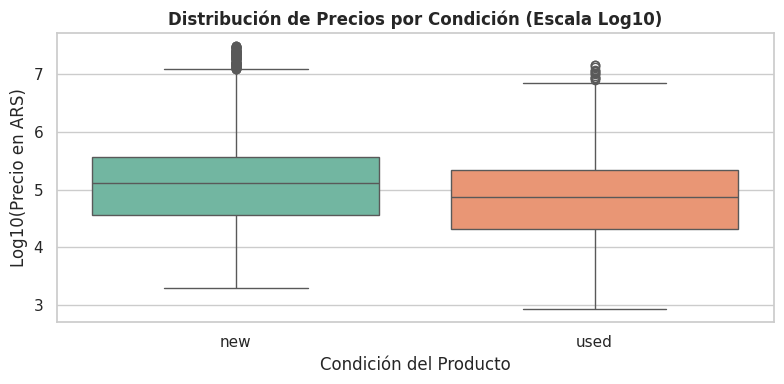

/tmp/ipykernel_2257/4056980609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=envio_ventas, x='shipping_type', y='Promedio_Venta', palette='Blues_d')


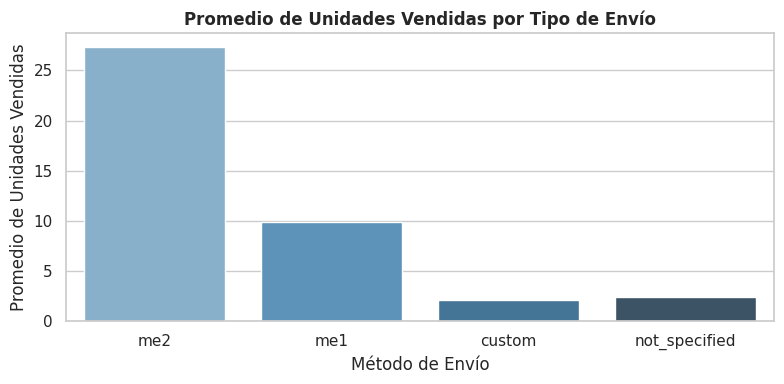

/tmp/ipykernel_2257/4056980609.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_cat, x='sold_quantity', y='category_id', palette='viridis')


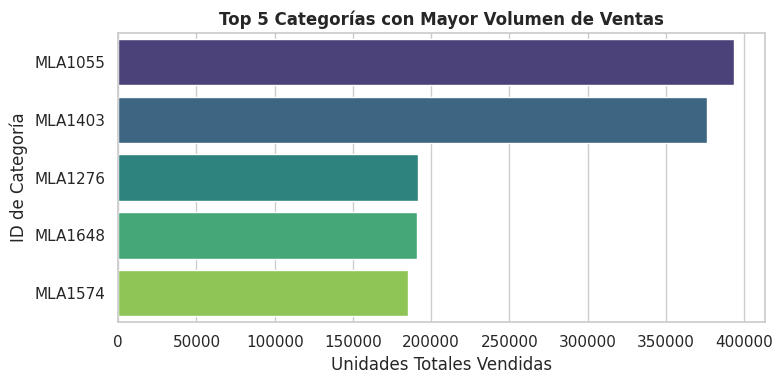

In [9]:
# Gráfico 1: Precios por condición en escala logarítmica
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x='condition', y=np.log10(df_clean['price']), palette='Set2')
plt.title("Distribución de Precios por Condición (Escala Log10)", fontsize=12, fontweight='bold')
plt.xlabel("Condición del Producto")
plt.ylabel("Log10(Precio en ARS)")
plt.tight_layout()
plt.show()

# Gráfico 2: Promedio de ventas según método logístico
plt.figure(figsize=(8, 4))
sns.barplot(data=envio_ventas, x='shipping_type', y='Promedio_Venta', palette='Blues_d')
plt.title("Promedio de Unidades Vendidas por Tipo de Envío", fontsize=12, fontweight='bold')
plt.xlabel("Método de Envío")
plt.ylabel("Promedio de Unidades Vendidas")
plt.tight_layout()
plt.show()

# Gráfico 3: Top 5 categorías
plt.figure(figsize=(8, 4))
sns.barplot(data=top_5_cat, x='sold_quantity', y='category_id', palette='viridis')
plt.title("Top 5 Categorías con Mayor Volumen de Ventas", fontsize=12, fontweight='bold')
plt.xlabel("Unidades Totales Vendidas")
plt.ylabel("ID de Categoría")
plt.tight_layout()
plt.show()